In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


In [31]:
df = pd.read_csv("sensor_training_data.csv")

In [32]:
df.drop(columns=["Timestamp"], inplace=True, errors='ignore')

In [33]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 MQ5A0      0
MQ5D0      0
MQ135A0    0
MQ135D0    0
DHT11_T    0
DHT11_H    0
Outcome    0
dtype: int64


In [34]:
print("Dataset Info:\n", df.info())
print("Dataset Description:\n", df.describe())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3917 entries, 0 to 3916
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   MQ5A0    3917 non-null   int64
 1   MQ5D0    3917 non-null   int64
 2   MQ135A0  3917 non-null   int64
 3   MQ135D0  3917 non-null   int64
 4   DHT11_T  3917 non-null   int64
 5   DHT11_H  3917 non-null   int64
 6   Outcome  3917 non-null   int64
dtypes: int64(7)
memory usage: 214.3 KB
Dataset Info:
 None
Dataset Description:
              MQ5A0        MQ5D0      MQ135A0  MQ135D0      DHT11_T  \
count  3917.000000  3917.000000  3917.000000   3917.0  3917.000000   
mean    446.978810     0.782487    97.045188      1.0    35.548124   
std      96.066392     0.412607    23.545281      0.0     3.003921   
min     254.000000     0.000000    46.000000      1.0    31.000000   
25%     367.000000     1.000000    72.000000      1.0    33.000000   
50%     424.000000     1.000000   103.000000      1.0    37.000000  

,MQ5A0,MQ5D0,MQ135A0,MQ135D0,DHT11_T,DHT11_H,Outcome
0,523,1,46,1,31,57,0
1,523,1,46,1,31,57,0
2,522,1,46,1,31,57,0
3,445,1,52,1,31,57,0
4,441,1,51,1,31,57,0


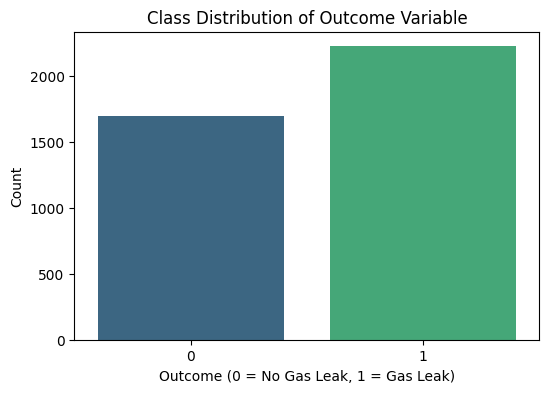

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Outcome", hue="Outcome", palette="viridis", legend=False)
plt.title("Class Distribution of Outcome Variable")
plt.xlabel("Outcome (0 = No Gas Leak, 1 = Gas Leak)")
plt.ylabel("Count")
plt.show()


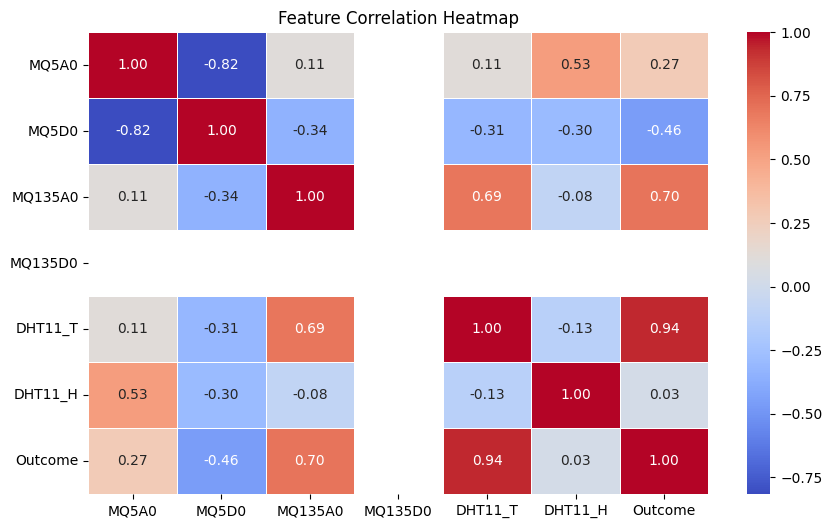

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [37]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3133, 6)
Testing Data Shape: (784, 6)


In [40]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
log_reg = GridSearchCV(LogisticRegression(), param_grid, cv=5)
log_reg.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100]})

In [41]:
best_log_reg = log_reg.best_estimator_
print("Best Logistic Regression Model:", best_log_reg)

Best Logistic Regression Model: LogisticRegression(C=0.01)


In [42]:
y_pred = best_log_reg.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)


Test Accuracy: 1.0


In [43]:
coefficients = best_log_reg.coef_[0]
intercept = best_log_reg.intercept_[0]

In [44]:
equation = f"{intercept:.4f} " + " ".join([f"+ ({coeff:.4f} * x_{i+1})" for i, coeff in enumerate(coefficients)])
print("Final Equation for Arduino:")
print("y =", equation)

Final Equation for Arduino:
y = 0.5133 + (0.1552 * x_1) + (-0.5094 * x_2) + (0.7950 * x_3) + (0.0000 * x_4) + (2.0366 * x_5) + (0.2274 * x_6)


In [46]:
import numpy as np
import pandas as pd

def continual_update(model, scaler, feature_names):
    """
    Takes new sensor values and target input from user,
    updates the logistic regression model (SGDClassifier),
    and prints new weights.
    """
    # Step 1: Get user input
    user_input = input(f"Enter new feature values for {feature_names} (comma-separated): ")
    values = list(map(float, user_input.split(',')))
    y_val = int(input("Enter the true label (0 or 1): "))

    # Step 2: Prepare new data
    new_data = pd.DataFrame([values], columns=feature_names)
    X_new_scaled = scaler.transform(new_data)

    # Step 3: Update model (continual learning step)
    model.partial_fit(X_new_scaled, [y_val])

    # Step 4: Show updated weights
    coef = model.coef_[0]
    intercept = model.intercept_[0]
    print("\n✅ Model updated successfully!")
    print("\nNew Logistic Regression Equation:")
    print(f"logit(p) = ({' + '.join([f'{coef[i]:.4f}*{feature_names[i]}' for i in range(len(feature_names))])}) + ({intercept:.4f})")

    return model
